In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from math import ceil
from sklearn.metrics import confusion_matrix
from time import time
from torch.utils.data import DataLoader, random_split

torch.manual_seed(0)
sns.set_theme()

# Загрузка, нормализация и разбиение данных

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transform, download=True
)

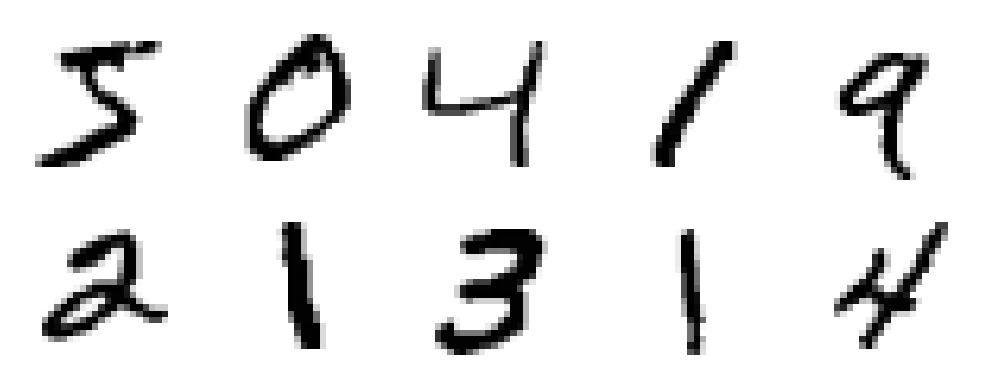

In [3]:
_, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
axes = axes.flatten()

for i, ax in enumerate(axes):
    image, _ = full_train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray_r")
    ax.axis("off")

plt.tight_layout()

In [4]:
print(
    f"Количество изображений для обучения: {len(full_train_dataset)}",
    f"Количество тестовых изображений: {len(test_dataset)}",
    f"Формат одного изображения: {full_train_dataset[0][0].shape}",
    f"Пример истинной метки: {full_train_dataset[0][1]}",
    sep="\n"
)

Количество изображений для обучения: 60000
Количество тестовых изображений: 10000
Формат одного изображения: torch.Size([1, 28, 28])
Пример истинной метки: 5


In [5]:
valid_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - valid_size

train_dataset, valid_dataset = random_split(
    full_train_dataset, [train_size, valid_size]
)

print(
    f"Размер обучающей выборки: {len(train_dataset)}",
    f"Размер валидационной выборки: {len(valid_dataset)}",
    sep="\n"
)

Размер обучающей выборки: 48000
Размер валидационной выборки: 12000


In [6]:
batch_size = 512

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))

print(
    f"Форма батча изображений: {batch_images.shape}",
    f"Форма батча меток: {batch_labels.shape}",
    sep="\n"
)

Форма батча изображений: torch.Size([512, 1, 28, 28])
Форма батча меток: torch.Size([512])


# Создание моделей

In [7]:
class MLP(nn.Module):
    def __init__(self, layer_sizes, activation):
        super().__init__()

        if len(layer_sizes) < 3:
            return ValueError("Ошибка: MLP должен включать как минимум 3 слоя")

        if activation not in ["relu", "sigmoid", "tanh"]:
            return ValueError("Ошибка: недопустимое значение activation")

        self.layers = nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            self.layers.append(
                nn.Linear(layer_sizes[i], layer_sizes[i + 1])
            )
        
        self.activation = activation
    
    def forward(self, x):
        # Преобразование входных данных в одномерный вектор
        # Пример: torch.Size([batch_size, 1, 28, 28]) -> torch.Size([batch_size, 784])
        x = x.view(x.size(0), -1)

        for layer in self.layers[:-1]:
            x = layer(x)

            if self.activation == "relu":
                x = torch.relu(x)
            elif self.activation == "sigmoid":
                x = torch.sigmoid(x)
            elif self.activation == "tanh":
                x = torch.tanh(x)
        
        # Последний слой не имеет активации и использует кросс-энтропию
        x = self.layers[-1](x)

        return x


def train_epoch(model, loader, optimizer, criterion, device):
    # Переключение модели в режим обучения
    model.train()

    running_loss = 0.0  # суммарная ошибка
    correct = 0  # количество правильных ответов
    total = 0  # общее число обработанных примеров

    # Проход по батчам данных
    for data, target in loader:
        # Перемещение тензоров на указанный CPU или GPU
        data, target = data.to(device), target.to(device)

        # Обнуление градиентов перед вычислением градиентов нового батча
        optimizer.zero_grad()
        # Прямой проход: получение сырых предсказаний
        output = model(data)
        # Вычисление функции потерь
        loss = criterion(output, target)
        # Обратный проход: вычисление градиентов функции потерь по всем параметрам модели
        loss.backward()
        # Обновление весов модели
        optimizer.step()
        
        # Прибавление суммарных потерь для всех примеров батча
        running_loss += loss.item() * data.size(0)
        # Получение предсказанных классов
        _, predicted = torch.max(output, 1)
        # Прибавление количества обработанных примеров
        total += target.size(0)
        # Прибавление количества верных ответов
        correct += (predicted == target).sum().item()
    
    # Вычисление средних потерь за эпоху
    epoch_loss = running_loss / total
    # Вычисление точности за эпоху
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    # Переключение модели в режим оценки
    model.eval()

    running_loss = 0.0  # суммарная ошибка
    correct = 0  # количество правильных ответов
    total = 0  # общее число обработанных примеров

    # Отключение автоматического вычисления градиентов
    with torch.no_grad():
        # Проход по батчам данных
        for data, target in loader:
            # Перемещение тензоров на указанный CPU или GPU
            data, target = data.to(device), target.to(device)

            # Прямой проход: получение сырых предсказаний
            output = model(data)
            # Вычисление функции потерь
            loss = criterion(output, target)

            # Прибавление суммарных потерь для всех примеров батча
            running_loss += loss.item() * data.size(0)
            # Получение предсказанных классов
            _, predicted = torch.max(output, 1)
            # Прибавление количества обработанных примеров
            total += target.size(0)
            # Прибавление количества верных ответов
            correct += (predicted == target).sum().item()
    
    # Вычисление средних потерь за эпоху
    epoch_loss = running_loss / total
    # Вычисление точности за эпоху
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def predict(model, loader, device):
    # Переключение модели в режим оценки
    model.eval()

    # Список для тензоров вероятностей
    all_probs = []

    # Отключение автоматического вычисления градиентов
    with torch.no_grad():
        # Проход по батчам данных
        for data, _ in loader:
            # Перемещение тензоров на указанный CPU или GPU
            data = data.to(device)
            
            # Прямой проход: получение сырых предсказаний (логитов)
            output = model(data)

            # Преобразование логитов в вероятности распределения по классам
            probs = torch.softmax(output, dim=1)

            # Перемещение тензоров с GPU на CPU при необходимости
            # и добавление в список тензора вида (batch_size, 10)
            all_probs.append(probs.cpu())
    
    # Объединение списка тензоров в один массив вида (loader_size, 10)
    return torch.cat(all_probs).numpy()

In [8]:
(current_device := torch.device("cuda" if torch.cuda.is_available() else "cpu"))

device(type='cpu')

In [9]:
layer_sizes_2 = [784, 128, 64, 10]
layer_sizes_3 = [784, 256, 128, 64, 10]
layer_sizes_4 = [784, 512, 256, 128, 64, 10]

opt_kwargs_adam = {"lr": 0.001}
opt_kwargs_adagrad = {"lr": 0.01}
opt_kwargs_rmsprop = {"lr": 0.001}

experiments = [
    ("MLP_2_ReLU_Adam", layer_sizes_2, "relu", "adam", opt_kwargs_adam),
    ("MLP_3_ReLU_Adam", layer_sizes_3, "relu", "adam", opt_kwargs_adam),

    ("MLP_4_ReLU_Adam", layer_sizes_4, "relu", "adam", opt_kwargs_adam),
    ("MLP_4_ReLU_AdaGrad", layer_sizes_4, "relu", "adagrad", opt_kwargs_adagrad),
    ("MLP_4_ReLU_RMSprop", layer_sizes_4, "relu", "rmsprop", opt_kwargs_rmsprop),

    ("MLP_4_Sigmoid_Adam", layer_sizes_4, "sigmoid", "adam", opt_kwargs_adam),
    ("MLP_4_Sigmoid_AdaGrad", layer_sizes_4, "sigmoid", "adagrad", opt_kwargs_adagrad),
    ("MLP_4_Sigmoid_RMSprop", layer_sizes_4, "sigmoid", "rmsprop", opt_kwargs_rmsprop),

    ("MLP_4_Tanh_Adam", layer_sizes_4, "tanh", "adam", opt_kwargs_adam),
    ("MLP_4_Tanh_AdaGrad", layer_sizes_4, "tanh", "adagrad", opt_kwargs_adagrad),
    ("MLP_4_Tanh_RMSprop", layer_sizes_4, "tanh", "rmsprop", opt_kwargs_rmsprop),
]

models = {}
experiments_list = []

for model_name, layer_sizes, activation, opt_name, opt_kwargs in experiments:
    model = MLP(layer_sizes, activation)
    model = model.to(current_device)
    models[model_name] = model

    model_name_parts = model_name.split("_")

    experiments_list.append({
        "Модель": model_name,
        "Размеры слоёв": layer_sizes,
        "Параметров": sum(p.numel() for p in model.parameters()),
        "Функция": model_name_parts[2],
        "Оптимизатор": model_name_parts[3],
    })

experiments_df = pd.DataFrame(experiments_list)
experiments_df.style.hide(axis="index")

Модель,Размеры слоёв,Параметров,Функция,Оптимизатор
MLP_2_ReLU_Adam,"[784, 128, 64, 10]",109386,ReLU,Adam
MLP_3_ReLU_Adam,"[784, 256, 128, 64, 10]",242762,ReLU,Adam
MLP_4_ReLU_Adam,"[784, 512, 256, 128, 64, 10]",575050,ReLU,Adam
MLP_4_ReLU_AdaGrad,"[784, 512, 256, 128, 64, 10]",575050,ReLU,AdaGrad
MLP_4_ReLU_RMSprop,"[784, 512, 256, 128, 64, 10]",575050,ReLU,RMSprop
MLP_4_Sigmoid_Adam,"[784, 512, 256, 128, 64, 10]",575050,Sigmoid,Adam
MLP_4_Sigmoid_AdaGrad,"[784, 512, 256, 128, 64, 10]",575050,Sigmoid,AdaGrad
MLP_4_Sigmoid_RMSprop,"[784, 512, 256, 128, 64, 10]",575050,Sigmoid,RMSprop
MLP_4_Tanh_Adam,"[784, 512, 256, 128, 64, 10]",575050,Tanh,Adam
MLP_4_Tanh_AdaGrad,"[784, 512, 256, 128, 64, 10]",575050,Tanh,AdaGrad


# Обучение моделей

In [10]:
criterion = nn.CrossEntropyLoss()
n_epochs = 15

histories = {}

for model_name, _, _, opt_name, opt_kwargs in experiments:
    print(f"Обучение модели '{model_name}':")

    model = models[model_name]
    
    if opt_name == "adam":
        optimizer = optim.Adam(model.parameters(), **opt_kwargs)
    elif opt_name == "adagrad":
        optimizer = optim.Adagrad(model.parameters(), **opt_kwargs)
    elif opt_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), **opt_kwargs)
    
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    start_time = time()
    
    for epoch in range(n_epochs):
        epoch_start_time = time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, current_device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, current_device)

        epoch_end_time = time()
        epoch_time = round(epoch_end_time - epoch_start_time)
        
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)
        
        print(f"Epoch {epoch + 1:2d}/{n_epochs} ({epoch_time}s) - "
              f"train_acc: {train_acc:.4f} - train_loss: {train_loss:.4f} - "
              f"valid_acc: {valid_acc:.4f} - valid_loss: {valid_loss:.4f}")
    
    end_time = time()
    elapsed_time = round(end_time - start_time)
    print(f"Время обучения модели '{model_name}': {elapsed_time} секунд\n")
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, current_device)

    torch.save(model.state_dict(), f"./models/{model_name}.pt")
    
    histories[model_name] = {
        "train_losses": train_losses,
        "train_accs": train_accs,
        "valid_losses": valid_losses,
        "valid_accs": valid_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
    }

Обучение модели 'MLP_2_ReLU_Adam':
Epoch  1/15 (5s) - train_acc: 0.7860 - train_loss: 0.8670 - valid_acc: 0.9047 - valid_loss: 0.3403
Epoch  2/15 (6s) - train_acc: 0.9173 - train_loss: 0.2901 - valid_acc: 0.9250 - valid_loss: 0.2580
Epoch  3/15 (6s) - train_acc: 0.9358 - train_loss: 0.2246 - valid_acc: 0.9414 - valid_loss: 0.2111
Epoch  4/15 (6s) - train_acc: 0.9470 - train_loss: 0.1876 - valid_acc: 0.9465 - valid_loss: 0.1853
Epoch  5/15 (5s) - train_acc: 0.9553 - train_loss: 0.1565 - valid_acc: 0.9521 - valid_loss: 0.1650
Epoch  6/15 (6s) - train_acc: 0.9604 - train_loss: 0.1351 - valid_acc: 0.9583 - valid_loss: 0.1455
Epoch  7/15 (6s) - train_acc: 0.9667 - train_loss: 0.1155 - valid_acc: 0.9616 - valid_loss: 0.1320
Epoch  8/15 (6s) - train_acc: 0.9700 - train_loss: 0.1021 - valid_acc: 0.9633 - valid_loss: 0.1243
Epoch  9/15 (6s) - train_acc: 0.9741 - train_loss: 0.0887 - valid_acc: 0.9661 - valid_loss: 0.1128
Epoch 10/15 (6s) - train_acc: 0.9770 - train_loss: 0.0783 - valid_acc: 0.9

In [11]:
results_list = []

for model_name, history in histories.items():
    results_list.append({
        "model": model_name,
        "train_loss": f"{history["train_losses"][-1]:.4f}",
        "train_acc": f"{history["train_accs"][-1]:.4f}",
        "valid_loss": f"{history["valid_losses"][-1]:.4f}",
        "valid_acc": f"{history["valid_accs"][-1]:.4f}",
        "test_loss": f"{history["test_loss"]:.4f}",
        "test_acc": f"{history["test_acc"]:.4f}",
    })

results_df = pd.DataFrame(results_list)
results_df.style.hide(axis="index")

model,train_loss,train_acc,valid_loss,valid_acc,test_loss,test_acc
MLP_2_ReLU_Adam,0.0457,0.9867,0.0945,0.9725,0.0818,0.9751
MLP_3_ReLU_Adam,0.0236,0.9931,0.0970,0.9715,0.0850,0.9765
MLP_4_ReLU_Adam,0.0075,0.9979,0.0977,0.9777,0.0936,0.9778
MLP_4_ReLU_AdaGrad,0.0077,0.9986,0.0844,0.9778,0.0753,0.9805
MLP_4_ReLU_RMSprop,0.0060,0.9986,0.1343,0.9680,0.1299,0.9690
MLP_4_Sigmoid_Adam,0.0676,0.9829,0.1308,0.9657,0.1233,0.9663
MLP_4_Sigmoid_AdaGrad,0.1517,0.9648,0.1793,0.9550,0.1815,0.9566
MLP_4_Sigmoid_RMSprop,0.0970,0.9741,0.1344,0.9626,0.1349,0.9636
MLP_4_Tanh_Adam,0.0153,0.9955,0.1005,0.9734,0.0999,0.9737
MLP_4_Tanh_AdaGrad,0.0405,0.9903,0.0971,0.9718,0.0890,0.9740


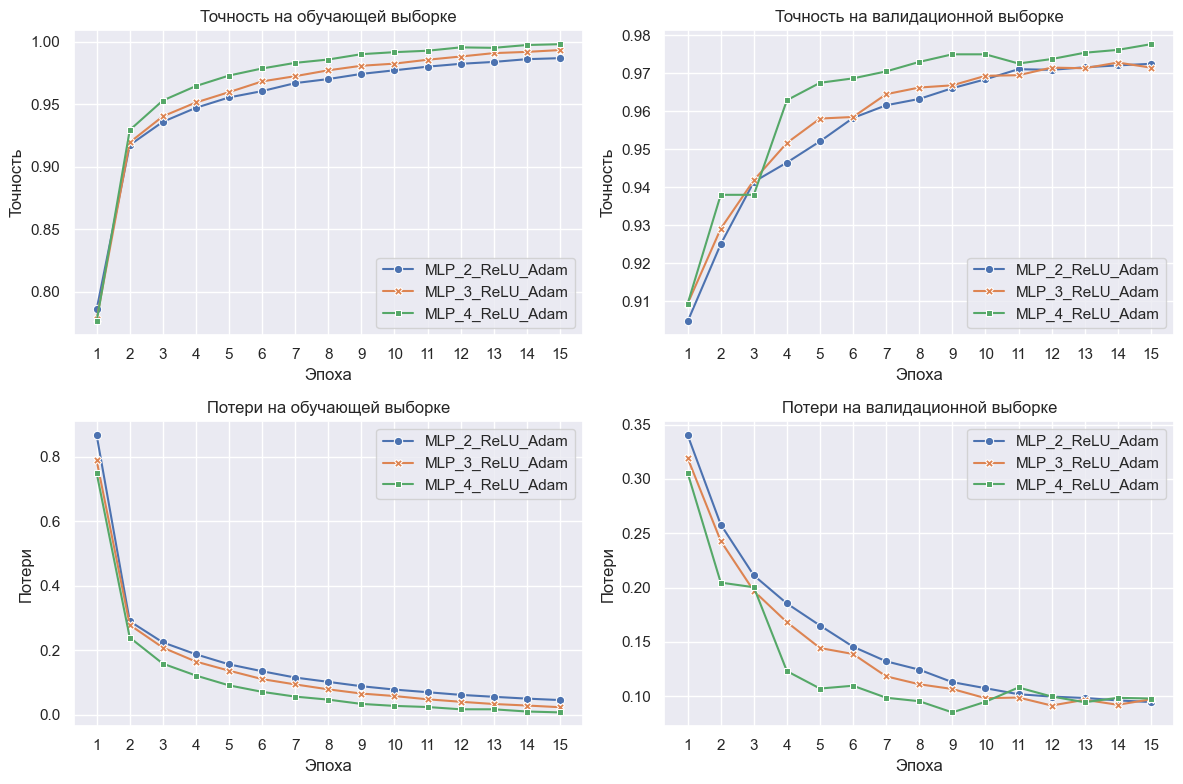

In [12]:
model_names_3, histories_list_3 = [], []
for _, model_name, history in zip(range(3), histories.keys(), histories.values()):
    model_names_3.append(model_name)
    histories_list_3.append(history)

records_list_3 = []

for model, history in zip(model_names_3, histories_list_3):
    for epoch, (train_acc, valid_acc, train_loss, valid_loss) in enumerate(zip(
        history["train_accs"], history["valid_accs"],
        history["train_losses"], history["valid_losses"],
    )):
        records_list_3.append({
            "model": model,
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "valid_acc": valid_acc,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
        })

records_df_3 = pd.DataFrame(records_list_3)

plot_params = {
    "y": ["train_acc", "valid_acc", "train_loss", "valid_loss"],
    "title": [
        "Точность на обучающей выборке",
        "Точность на валидационной выборке",
        "Потери на обучающей выборке",
        "Потери на валидационной выборке"
    ],
    "ylabel": ["Точность", "Точность", "Потери", "Потери"],
}

n_rows, n_cols = 2, 2
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 8))
axes = axes.flatten()

for i in range(len(axes)):
    sns.lineplot(
        data=records_df_3, x="epoch", y=plot_params["y"][i], hue="model",
        style="model", dashes=False, markers=True, ax=axes[i]
    ).set(
        title=plot_params["title"][i], xlabel="Эпоха",
        ylabel=plot_params["ylabel"][i], xticks=range(1, n_epochs + 1)
    )
    axes[i].legend(title="", loc="lower right" if i < 2 else "upper right")

plt.tight_layout()

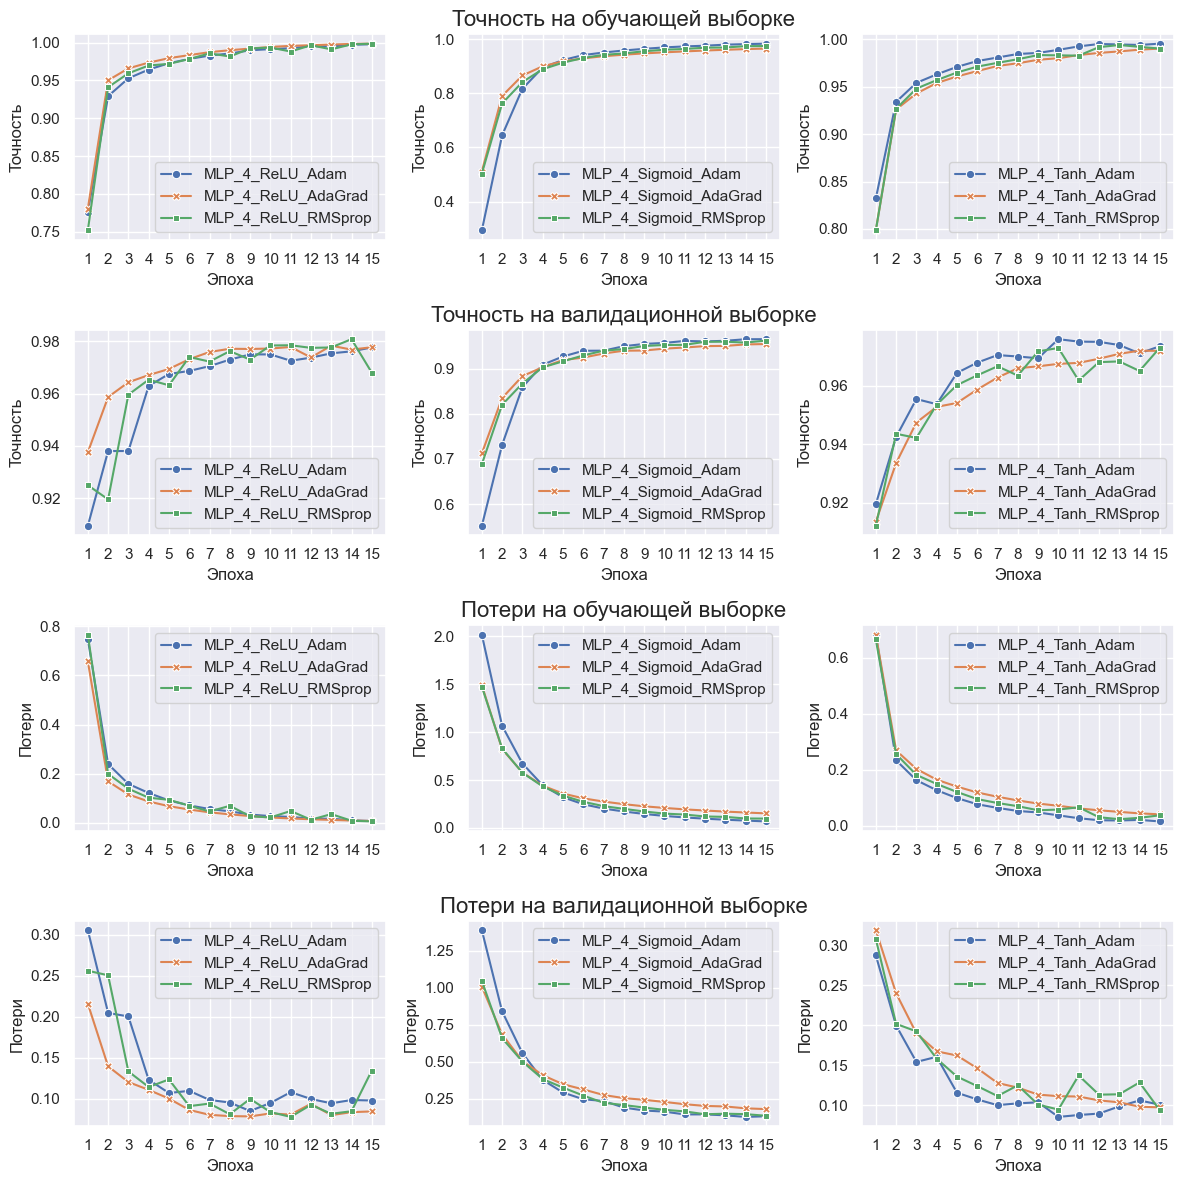

In [13]:
model_names_9, histories_list_9 = [], []
for i, model_name, history in zip(range(len(histories)), histories.keys(), histories.values()):
    if i < 2:
        continue
    model_names_9.append(model_name)
    histories_list_9.append(history)

records_list_9 = []

for model, history in zip(model_names_9, histories_list_9):
    for epoch, (train_acc, valid_acc, train_loss, valid_loss) in enumerate(zip(
        history["train_accs"], history["valid_accs"], history["train_losses"], history["valid_losses"]
    )):
        records_list_9.append({
            "model": model,
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "valid_acc": valid_acc,
            "train_loss": train_loss,
            "valid_loss": valid_loss
        })

records_df_9 = pd.DataFrame(records_list_9)

n_rows, n_cols = 4, 3
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 12))

for i in range(n_rows):
    for j in range(n_cols):
        n_values = n_epochs * n_cols

        sns.lineplot(
            data=records_df_9[j * n_values : j * n_values + n_values],
            x="epoch", y=plot_params["y"][i], hue="model",
            style="model", dashes=False, markers=True, ax=axes[i, j]
        ).set(
            xlabel="Эпоха", ylabel=plot_params["ylabel"][i], xticks=range(1, n_epochs + 1)
        )

        axes[i, j].set_title(plot_params["title"][i] if j == 1 else "", fontsize=16)
        axes[i, j].legend(title="")

plt.tight_layout()

# Тестирование и оценка качества моделей

In [14]:
for model_name, model in models.items():
    model.load_state_dict(torch.load(f"./models/{model_name}.pt"))

In [15]:
y_true = test_dataset.targets.numpy()

preds = []

for model_name, model in models.items():
    y_pred_proba = predict(model, test_loader, current_device)

    y_pred = np.argmax(y_pred_proba, axis=1)

    cm = confusion_matrix(y_true, y_pred)

    preds.append((model_name, y_pred_proba, y_pred, cm))

preds[0]

('MLP_2_ReLU_Adam',
 array([[2.3105733e-06, 3.4595871e-07, 3.5654870e-05, ..., 9.9850392e-01,
         4.1100370e-06, 4.5526409e-05],
        [1.6641502e-08, 2.9516977e-03, 9.9695420e-01, ..., 1.3481956e-10,
         2.8981243e-05, 4.7513317e-12],
        [1.2160806e-06, 9.9804437e-01, 1.3457450e-04, ..., 9.3968073e-04,
         7.3943939e-04, 3.7410903e-06],
        ...,
        [2.7460878e-10, 5.5298299e-10, 6.7539196e-11, ..., 1.0108863e-05,
         5.1091288e-06, 1.4395535e-04],
        [4.6867343e-10, 2.3639866e-09, 5.6971527e-10, ..., 3.3786831e-11,
         5.0630886e-05, 1.1600775e-09],
        [1.4350050e-07, 1.3750076e-10, 1.1800871e-06, ..., 2.7084376e-12,
         2.9294736e-09, 1.4611323e-11]], shape=(10000, 10), dtype=float32),
 array([7, 2, 1, ..., 4, 5, 6], shape=(10000,)),
 array([[ 969,    0,    0,    2,    1,    1,    2,    1,    2,    2],
        [   0, 1126,    4,    0,    0,    1,    1,    0,    3,    0],
        [   2,    3, 1008,    3,    2,    0,    1,    5,  

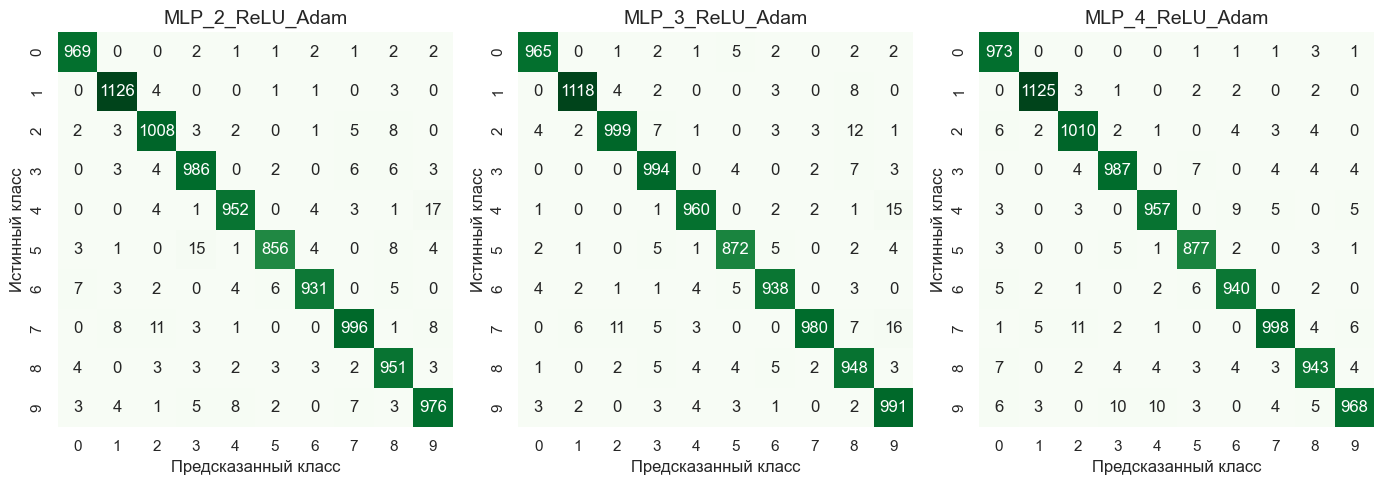

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for i, (model_name, _, _, cm) in enumerate(preds[:3]):
    sns.heatmap(
        cm, cmap="Greens", annot=True, fmt="d", cbar=False, square=True, ax=axes[i]
    ).set(
        xlabel="Предсказанный класс", ylabel="Истинный класс"
    )
    axes[i].set_title(model_name, fontsize=14)

plt.tight_layout()

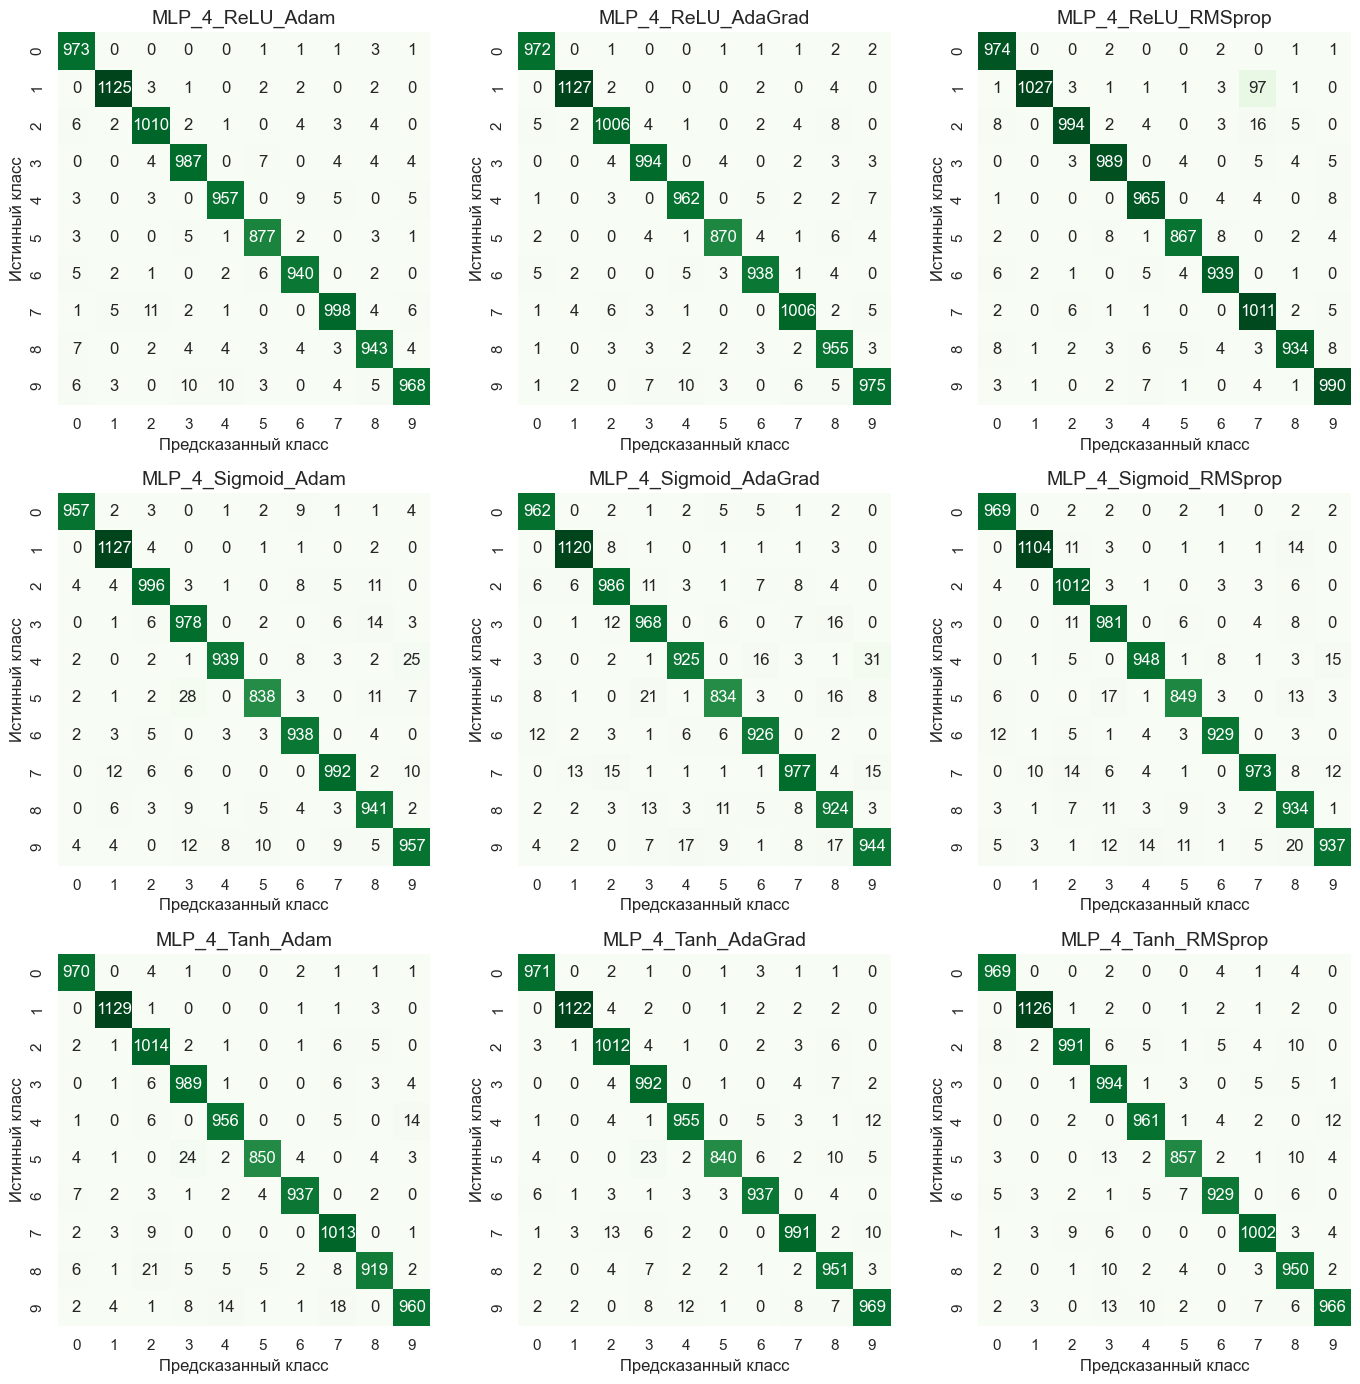

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 14))
axes = axes.flatten()

for i, (model_name, _, _, cm) in enumerate(preds[2:]):
    sns.heatmap(
        cm, cmap="Greens", annot=True, fmt="d", cbar=False, square=True, ax=axes[i]
    ).set(
        xlabel="Предсказанный класс", ylabel="Истинный класс"
    )
    axes[i].set_title(model_name, fontsize=14)

plt.tight_layout()

In [18]:
error_masks = []
errors = []

for i, (model_name, _, model_preds, _) in enumerate(preds):
    mask = (model_preds != y_true)
    error_masks.append(mask)

    n_errors = np.sum(mask)
    n_errors_by_class = np.bincount(y_true[mask], minlength=10)

    errors.append([model_name] + n_errors_by_class.tolist() + [n_errors])

errors_df = pd.DataFrame(
    errors, columns=["Модель"] + list(range(10)) + ["Всего"]
)
errors_df.style.hide(axis="index")

Модель,0,1,2,3,4,5,6,7,8,9,Всего
MLP_2_ReLU_Adam,11,9,24,24,30,36,27,32,23,33,249
MLP_3_ReLU_Adam,15,17,33,16,22,20,20,48,26,18,235
MLP_4_ReLU_Adam,7,10,22,23,25,15,18,30,31,41,222
MLP_4_ReLU_AdaGrad,8,8,26,16,20,22,20,22,19,34,195
MLP_4_ReLU_RMSprop,6,108,38,21,17,25,19,17,40,19,310
MLP_4_Sigmoid_Adam,23,8,36,32,43,54,20,36,33,52,337
MLP_4_Sigmoid_AdaGrad,18,15,46,42,57,58,32,51,50,65,434
MLP_4_Sigmoid_RMSprop,11,31,20,29,34,43,29,55,40,72,364
MLP_4_Tanh_Adam,10,6,18,21,26,42,21,15,55,49,263
MLP_4_Tanh_AdaGrad,9,13,20,18,27,52,21,37,23,40,260


In [19]:
error_indices = np.where(np.logical_and.reduce(error_masks))[0]
len(error_indices)

50

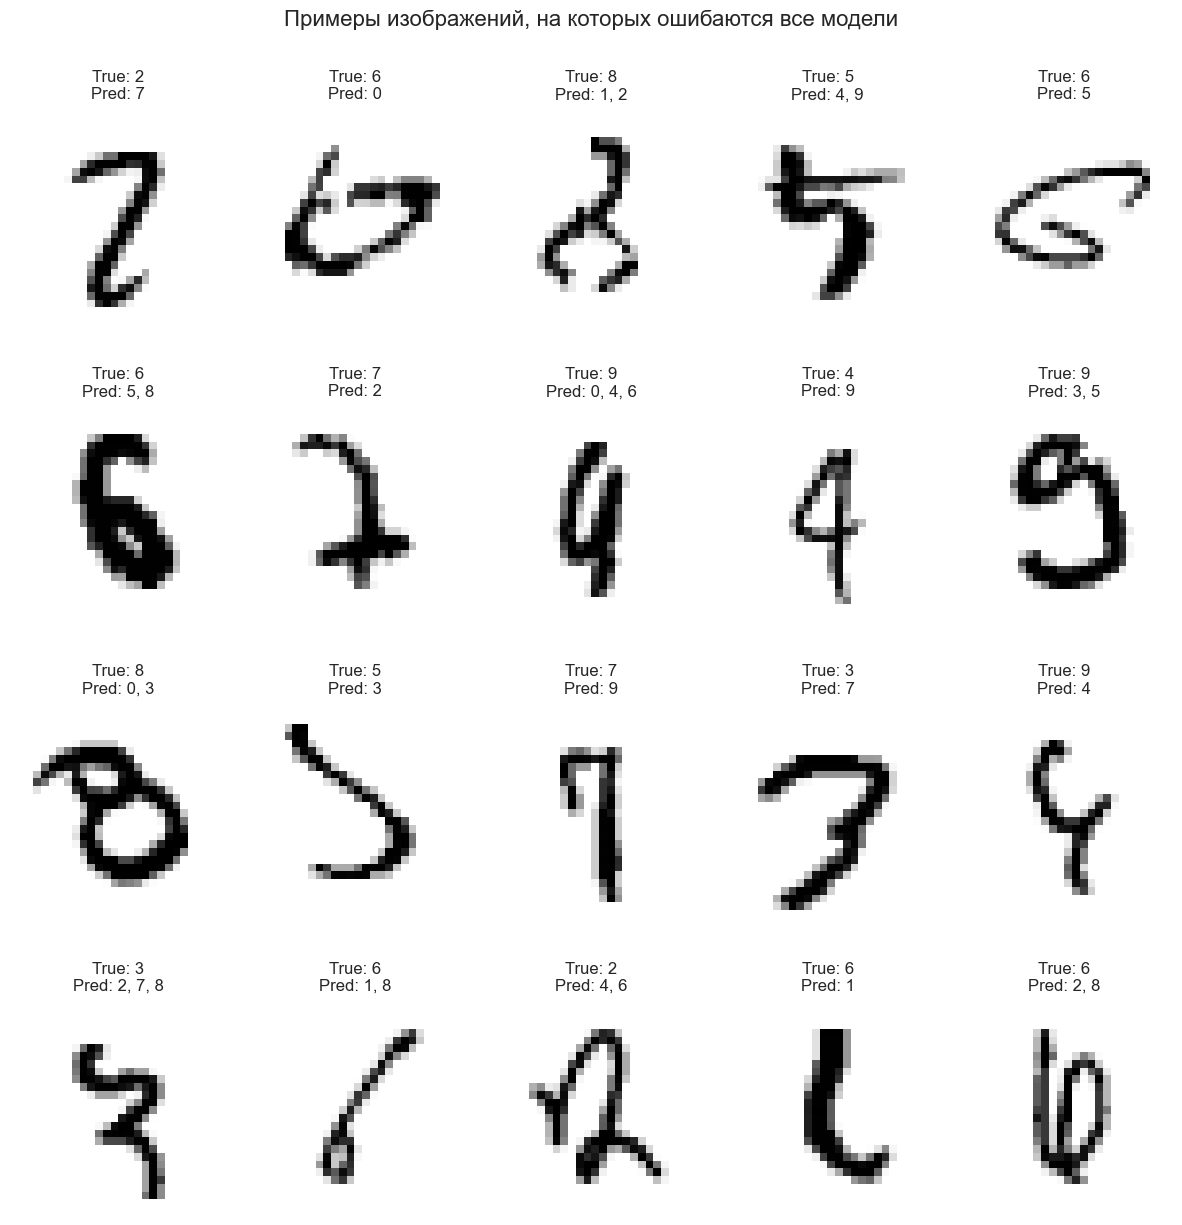

In [20]:
n_cols = 5
n_rows = ceil(min(20, len(error_indices)) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

fig.suptitle(
    f"Примеры изображений, на которых ошибаются все модели",
    fontsize=16, y=1.02
)

for ax, error_index in zip(axes, error_indices):
    image, _ = test_dataset[error_index]
    ax.imshow(image.squeeze(), cmap="gray_r")
    ax.axis("off")

    all_preds = [preds[i][2][error_index] for i in range(len(preds))]
    all_preds_str = ", ".join(map(str, sorted(set(all_preds))))
    ax.set_title(f"True: {y_true[error_index]}\nPred: {all_preds_str}")

for ax in axes[len(error_indices):]:
    ax.axis("off")

plt.tight_layout(h_pad=5)

In [21]:
error_indices_3 = np.where(
    (preds[0][2] != preds[1][2]) &
    (preds[1][2] != preds[2][2]) &
    (preds[0][2] != preds[2][2])
)[0]

len(error_indices_3)

26

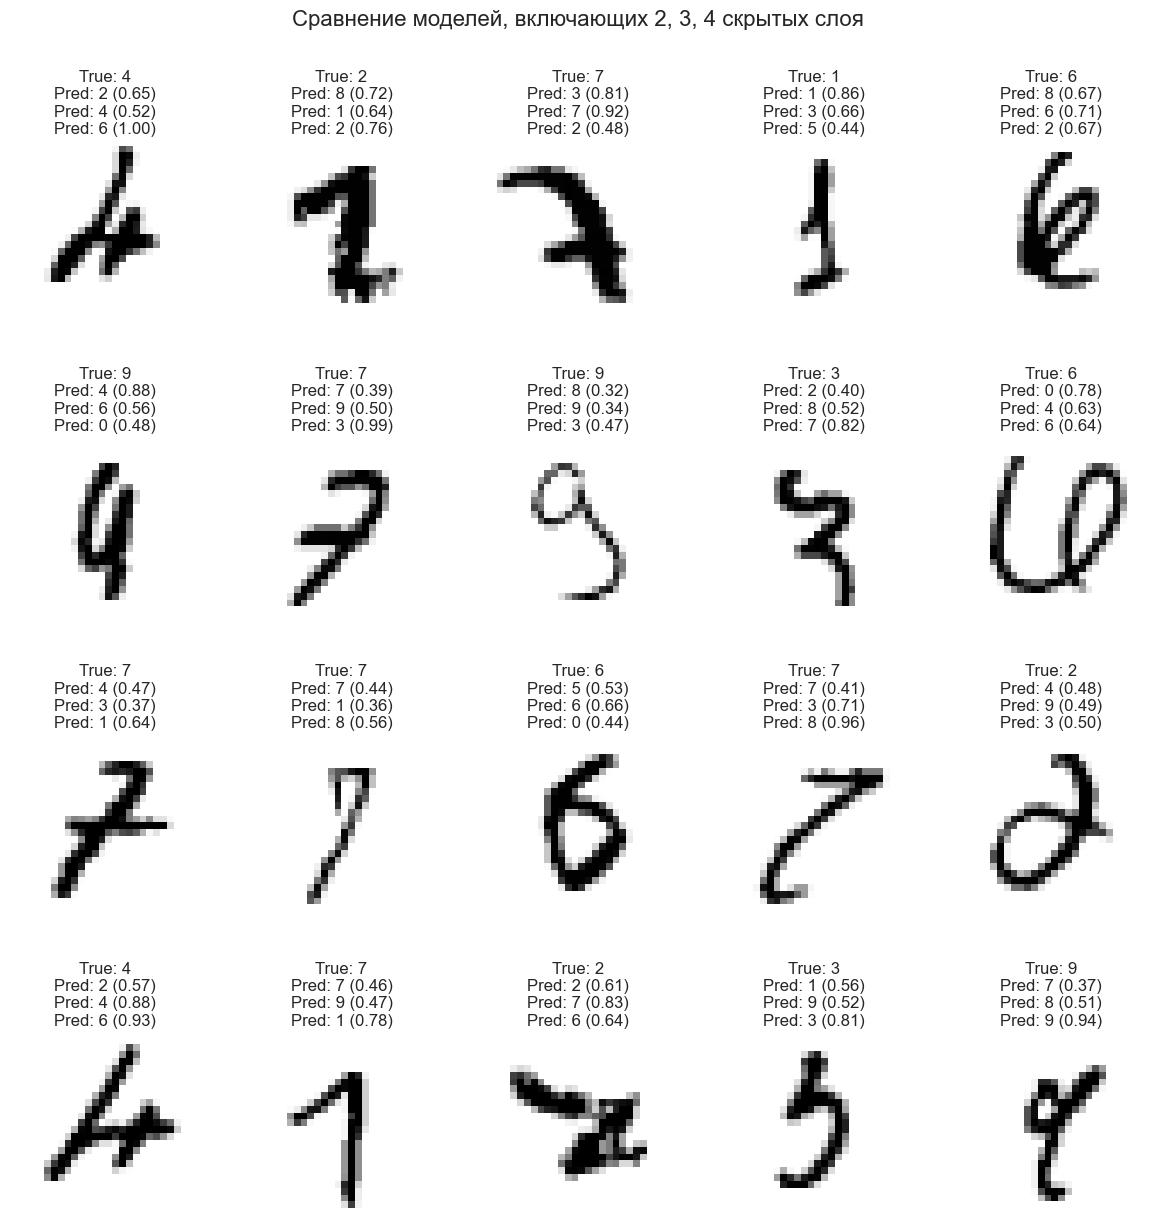

In [22]:
n_cols = 5
n_rows = ceil(min(20, len(error_indices_3)) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

fig.suptitle(
    f"Сравнение моделей, включающих 2, 3, 4 скрытых слоя",
    fontsize=16, y=1.02
)

for ax, error_index in zip(axes, error_indices_3):
    pred1 = preds[0][2][error_index]
    pred2 = preds[1][2][error_index]
    pred3 = preds[2][2][error_index]

    prob1 = preds[0][1][error_index][pred1]
    prob2 = preds[1][1][error_index][pred2]
    prob3 = preds[2][1][error_index][pred3]

    image, _ = test_dataset[error_index]
    ax.imshow(image.squeeze(), cmap="gray_r")
    ax.axis("off")
    ax.set_title(
        f"True: {y_true[error_index]}\n"
        f"Pred: {pred1} ({prob1:.2f})\n"
        f"Pred: {pred2} ({prob2:.2f})\n"
        f"Pred: {pred3} ({prob3:.2f})",
        pad=0
    )

for ax in axes[len(error_indices_3):]:
    ax.axis("off")

plt.tight_layout(h_pad=5)